## Deep Q-Learning - Lunar Lander

In [1]:
import gym
import random
import time
from collections import deque, namedtuple
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from pyvirtualdisplay import Display
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import MSE
from tensorflow.keras.optimizers import Adam
import utils
import warnings
import cv2
import os

warnings.simplefilter(action='ignore', category=Warning)

In [2]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-3              # learning rate
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps

### The Lunar Lander Environment

In this notebook we will be using OpenAI's Gym Library. The Gym library provides a wide variety of environments for reinforcement learning. To put it simply, an environment represents a problem or task to be solved. In this notebook, we will try to solve the Lunar Lander environment using reinforcement learning.

The goal of the Lunar Lander environment is to land the lunar lander safely on the landing pad on the surface of the moon. The landing pad is designated by two flag poles and its center is at coordinates `(0,0)` but the lander is also allowed to land outside of the landing pad. The lander starts at the top center of the environment with a random initial force applied to its center of mass and has infinite fuel. The environment is considered solved if you get `200` points. 

### Action Space

The agent has four discrete actions available:

* Do nothing.
* Fire right engine.
* Fire main engine.
* Fire left engine.

Each action has a corresponding numerical value:

```python
Do nothing = 0
Fire right engine = 1
Fire main engine = 2
Fire left engine = 3
```

### Observation Space

The agent's observation space consists of a state vector with 8 variables:

* Its $(x,y)$ coordinates. The landing pad is always at coordinates $(0,0)$.
* Its linear velocities $(\dot x,\dot y)$.
* Its angle $\theta$.
* Its angular velocity $\dot \theta$.
* Two booleans, $l$ and $r$, that represent whether each leg is in contact with the ground or not.

### Rewards

After every step, a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:
- is increased/decreased the closer/further the lander is to the landing pad.
- is increased/decreased the slower/faster the lander is moving.
- is decreased the more the lander is tilted (angle not horizontal).
- is increased by 10 points for each leg that is in contact with the ground.
- is decreased by 0.03 points each frame a side engine is firing.
- is decreased by 0.3 points each frame the main engine is firing.

The episode receives an additional reward of -100 or +100 points for crashing or landing safely respectively.

### Episode Termination

An episode ends (i.e the environment enters a terminal state) if:

* The lunar lander crashes (i.e if the body of the lunar lander comes in contact with the surface of the moon).

* The absolute value of the lander's $x$-coordinate is greater than 1 (i.e. it goes beyond the left or right border)

In [3]:
# Load the enviroment
env = gym.make('LunarLander-v2', render_mode='rgb_array')

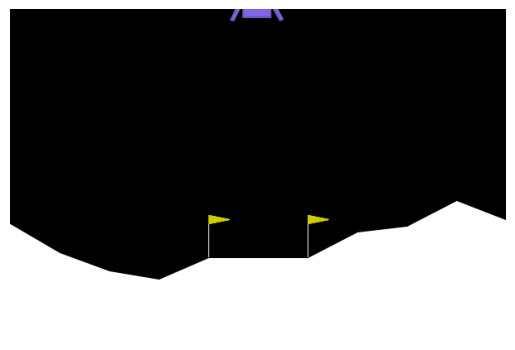

In [4]:
obs, info = env.reset()
frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

In [5]:
state_size = env.observation_space.shape
num_actions = env.action_space.n

print('State Shape:', state_size)
print('Number of actions:', num_actions)

State Shape: (8,)
Number of actions: 4


In [6]:
# Reset the environment and get the initial state.
current_state = env.reset()[0]

In [7]:
action = 0
next_state, reward, terminated, truncated, _ = env.step(action)

# Checking if the game ended
done = terminated or truncated  

utils.display_table(current_state, action, next_state, reward, done)

current_state = next_state

In [8]:
q_network = Sequential([
    Input(state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ])

target_q_network = Sequential([
    Input(state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ])

optimizer = Adam(learning_rate=ALPHA)

In [9]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

In [10]:
def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Keras model for predicting the targets
          
    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """

    states, actions, rewards, next_states, done_vals = experiences
    
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    y_targets = rewards + (gamma * max_qsa * (1 - done_vals))

    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))
        
    loss = MSE(q_values, y_targets)
    
    return loss

In [11]:
@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
    
    """
    
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    gradients = tape.gradient(loss, q_network.trainable_variables)
    
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    utils.update_target_network(q_network, target_q_network)

In [12]:
start = time.time()
num_episodes = 2000
max_num_timesteps = 1000
total_point_history = []
num_p_av = 100    # number of total points to use for averaging
epsilon = 1.0     # initial ε value for ε-greedy policy
# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)
# Set the target network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

for i in range(num_episodes):
    
    state_info = env.reset()
    state = state_info[0]
    
    total_points = 0
    
    for t in range(max_num_timesteps):
        state = np.array(state, dtype=np.float32)
        
        # From the current state S choose an action A using an ε-greedy policy
        state_qn = np.expand_dims(state, axis=0)  # state needs to be the right shape for the q_network
        q_values = q_network(state_qn)
        action = utils.get_action(q_values, epsilon)
        
        # Take action A and receive reward R and the next state S'
        # New gym API returns (next_state, reward, terminated, truncated, info)
        step_result = env.step(action)
        
        next_state, reward, terminated, truncated, info = step_result
        # In the new API, 'done' is when the episode is either terminated or truncated
        done = terminated or truncated
        
        # Ensure next_state is in the right format
        next_state = np.array(next_state, dtype=np.float32)
        
        # Store experience tuple (S,A,R,S') in the memory buffer.
        # We store the done variable as well for convenience.
        memory_buffer.append(experience(state, action, reward, next_state, done))
        
        # Only update the network every NUM_STEPS_FOR_UPDATE time steps.
        update = utils.check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
        
        if update:
            # Sample random mini-batch of experience tuples (S,A,R,S') from D
            experiences = utils.get_experiences(memory_buffer)
            
            # Set the y targets, perform a gradient descent step,
            # and update the network weights.
            agent_learn(experiences, GAMMA)
        
        state = next_state.copy()
        total_points += reward
        
        if done:
            break
            
    total_point_history.append(total_points)
    av_latest_points = np.mean(total_point_history[-num_p_av:])
    
    # Update the ε value
    epsilon = utils.get_new_eps(epsilon)
    print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")
    if (i+1) % num_p_av == 0:
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")
    # We will consider that the environment is solved if we get an
    # average of 200 points in the last 100 episodes.
    if av_latest_points >= 200.0:
        print(f"\n\nEnvironment solved in {i+1} episodes!")
        q_network.save('lunar_lander_model.h5')
        break
        
tot_time = time.time() - start
print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Episode 100 | Total point average of the last 100 episodes: -165.30
Episode 200 | Total point average of the last 100 episodes: -113.88
Episode 300 | Total point average of the last 100 episodes: -27.236
Episode 400 | Total point average of the last 100 episodes: 110.58
Episode 500 | Total point average of the last 100 episodes: 190.41
Episode 523 | Total point average of the last 100 episodes: 200.88

Environment solved in 523 episodes!

Total Runtime: 710.90 s (11.85 min)


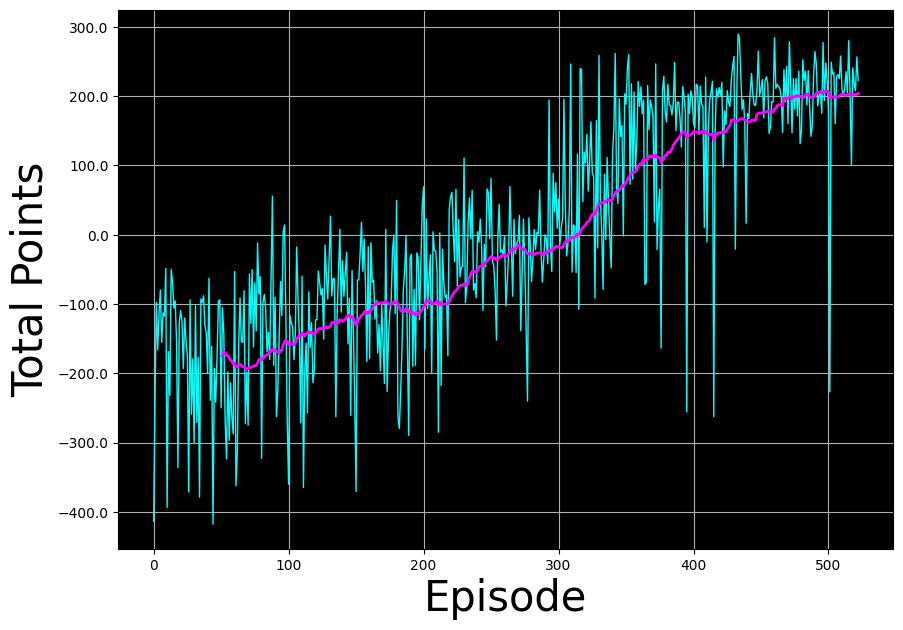

In [13]:
utils.plot_history(total_point_history)

In [14]:
def create_and_display_lunar_lander_video(model_path, output_filename, num_episodes=3):
    """
    Generates the video using with the trained Lunar Lender Model
    """
    os.makedirs(os.path.dirname(os.path.abspath(output_filename)), exist_ok=True)
    
    loaded_model = tf.keras.models.load_model(model_path, compile=False)
    
    loaded_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['accuracy']
    )
    
    env = gym.make('LunarLander-v2', render_mode='rgb_array')
    
    observation = env.reset()
    state = observation[0]
    
    frame = env.render()
    height, width, layers = frame.shape
    
    fourcc = cv2.VideoWriter_fourcc(*'XVID') 
    out_path = output_filename   # .replace('.mp4', '.avi')  
    video_writer = cv2.VideoWriter(out_path, fourcc, 30.0, (width, height))
    
    last_frame = None
    
    try:
        for episode in range(num_episodes):
            print(f"Episode {episode+1} recording...")
            
            observation = env.reset()
            state = observation[0]
            
            frame = env.render()
            last_frame = frame.copy()
            # Transfor RGB to BGR (for OpenCV)
            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            video_writer.write(frame_bgr)
            
            done = False
            total_reward = 0
            
            while not done:
                state_tensor = tf.convert_to_tensor(state[None, :], dtype=tf.float32)
                q_values = loaded_model(state_tensor)
                action = np.argmax(q_values[0])
                
                step_result = env.step(action)
                
                next_state, reward, terminated, truncated, _ = step_result
                done = terminated or truncated

                state = next_state
                total_reward += reward

                frame = env.render()
                last_frame = frame.copy()
                frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                video_writer.write(frame_bgr)
            
            print(f"Episode {episode+1} completed. Total score: {total_reward:.2f}")
        
        video_writer.release()
        print(f"Video saved succesfully: {out_path}")
        
        return out_path
        
    except Exception as e:
        video_writer.release()
        print(f"Error while generating the video: {e}")
        
        return None
    
    finally:
        env.close()

model_path = "lunar_lander_model.h5"  
output_path = "./videos/lunar_lander_demo.mp4"
video_path = create_and_display_lunar_lander_video(model_path, output_path)

Episode 1 recording...
Episode 1 completed. Total score: 232.00
Episode 2 recording...
Episode 2 completed. Total score: 242.93
Episode 3 recording...
Episode 3 completed. Total score: 136.06
Video saved succesfully: ./videos/lunar_lander_demo.mp4
